<div style="border:solid Chocolate 2px; padding: 40px">

<b>Привет!</b>

Меня зовут Евгений Головин, я буду ревьюером твоего проекта. Если ты не против, то предлагаю построить наше общение на "ты" ;) Если удобнее на "вы", то нет проблем, только скажи об этом. 

В ходе работы я оставил тебе комментарии <font color='green'>зеленого</font>, <font color='gold'>желтого</font> и <font color='red'>красного</font> цветов. Сейчас объясню, что они значат:

<br/>

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>

<b>Все супер!👍:</b> Решение на этом шаге является полностью правильным.
</div>

<br/>

<div class="alert alert-warning">
    <h2> Комментарий ревьюера <a class="tocSkip"> </h2>
    
<b>Небольшие замечания и рекомендации💡:</b> Решение на этом шаге станет еще лучше, если внести небольшие коррективы.
</div>


<br/>
<div class="alert alert-block alert-danger">
<h2> Комментарий ревьюера <a class="tocSkip"></h2>

    
<b>На доработку🤔:</b>
 Решение на этом шаге требует существенной переработки и внесения правок. Напоминаю, что проект не может быть принят с первого раза, если ревью содержит комментарии, рекомендующие доработать шаги.
</div>
    
Увидев мой комментарий, не удаляй его, он будет очень полезен в случае повторной проверки работы :)
    
<div class="alert alert-info">
<b>А свой помечай вот так, чтобы я его не потерял ;)</b> 
</div>
    
На мои комменатрии можно и нужно реагировать, только делать это стоит так, чтобы твои и мои комменты не смешались: выделяй свои цветами, сильно отличающимися от моих.
    
Увидев у тебя неточность, в первый раз я лишь укажу на ее наличие и дам тебе возможность самому найти и исправить ее. На реальной работе твой руководитель будет поступать также, и я пытаюсь подготовить тебя именно к работе аналитиком. Но если ты пока не справишься с такой задачей - при следующей проверке я дам более точную подсказку!

# Проект: семантический поиск товаров по текстовому запросу

**Ваша роль.** Вы специалист по Data Science. Компания развивает онлайн-каталог товаров, и сейчас руководству кажется, что классический поиск по ключевым словам плохо справляется с реальными запросами. Пользователи пишут названия с ошибками, кириллицей, используют просторечные слова, ищут товары по назначению, а не по функциональности («удобные кроссовки для бега» вместо «мужские спортивные кроссовки с амортизацией»). Команда хочет проверить, поможет ли векторный поиск улучшить качество поисковой системы.

**Задача.** Вам нужно построить MVP системы семантического поиска, сравнить его с лексической baseline-моделью на подготовленной разметке и дать бизнесу обоснованную рекомендацию о том, где новое решение помогает, где ошибается и стоит ли его вообще внедрять.

## Данные

| Файл | Что это | Когда нужен |
|---|---|---|
| wb_products_raw_sample.parquet | Исходный каталог, ~200 тысяч строк, все категории. <br> Вам нужно самостоятельно отобрать рабочее подмножество этих данных | Недели 1–2 |
| wb_products_dedup.parquet | Пул асессоров: множество товаров, по которому делалась разметка | Неделя 2, раздел 4 |
| queries_synthetic_train.parquet | Разметка релевантности, train | Недели 2–3 |
| queries_synthetic_test.parquet | Разметка релевантности, test | **один прогон** в конце недели 3 |

Файлы с разметкой содержат четыре столбца: `query_id`, `query_text`, `item_id`, `relevance`. Шкала в `relevance` от `0` до `3`, где `0` — товар нерелевантен, а `3` — максимально релевантен. Связь с каталогом: `item_id` ↔ `imt_id`.

## Импорты

In [1]:
import os
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer

# фиксируем случайность для воспроизводимости
SEED = 42
np.random.seed(SEED)

# доступы к S3 и MLflow читаются из .env
load_dotenv()

# ширина колонки
pd.set_option("display.max_colwidth", 200)

---

## Неделя 1 — знакомство с данными и EDA

**Цель** — понять, с какими данными работаете, чтобы принять обоснованные решения:

- выбрать категории, с которыми будете работать;
- определить, как будете очищать описания от всего лишнего;
- решить, из каких полей собирать текст товара.

**Главный критерий успеха:** любое ваше решение по данным вы можете подкрепить ссылкой на конкретные результаты анализа.

### 1. Загрузка данных

Загрузите каталог и обе разметки. Изучите их структуру: проанализируйте колонки и типы данных в них, определите, что описывает одна строка.

**Подсказка.** `imt_id` — карточка товара, `nm_id` — конкретный артикул этого товара, то есть его разновидность, отличающаяся цветом, размером или чем-то ещё. Определите, что из этого должен возвращать поиск, — от этого зависит, на каком уровне вы будете строить индекс.

In [2]:
# файлы ищем сначала локально в папке data, если там нет - читаем напрямую из s3
data_dir = "data"
s3_dir = "s3://s3-ds-source"

# доступ к s3 для pd.read_parquet
storage_options = {
    "key": os.getenv("S3_ACCESS_KEY"),
    "secret": os.getenv("S3_SECRET_KEY"),
    "client_kwargs": {"endpoint_url": os.getenv("S3_ENDPOINT_URL")},
    "default_cache_type": "all",  # качаем файл целиком, иначе чтение по кусочкам очень долгое
}


def read_data(file_name):
    local_path = os.path.join(data_dir, file_name)
    if os.path.exists(local_path):
        return pd.read_parquet(local_path)
    else:
        return pd.read_parquet(f"{s3_dir}/{file_name}", storage_options=storage_options)

In [3]:
df_raw = read_data("wb_products_raw_sample.parquet")
df_dedup = read_data("wb_products_dedup.parquet")
queries_train = read_data("queries_synthetic_train.parquet")
queries_test = read_data("queries_synthetic_test.parquet")

# размеры таблиц
print("каталог:", df_raw.shape)
print("пул асессоров:", df_dedup.shape)
print("train:", queries_train.shape)
print("test:", queries_test.shape)

каталог: (200000, 9)
пул асессоров: (4256, 9)
train: (11453, 4)
test: (4866, 4)


In [4]:
# колонки и типы каталога
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column           Non-Null Count   Dtype
---  ------           --------------   -----
 0   imt_id           200000 non-null  int64
 1   nm_id            200000 non-null  int64
 2   imt_name         200000 non-null  str  
 3   subj_name        200000 non-null  str  
 4   subj_root_name   200000 non-null  str  
 5   nm_colors_names  200000 non-null  str  
 6   vendor_code      200000 non-null  str  
 7   description      200000 non-null  str  
 8   brand_name       200000 non-null  str  
dtypes: int64(2), str(7)
memory usage: 169.5 MB


In [5]:
# первые строки каталога
df_raw.head()

,imt_id,nm_id,imt_name,subj_name,subj_root_name,nm_colors_names,vendor_code,description,brand_name
0,100000,118982,Сумка,Сумки,Аксессуары,бежевый,82992/beige,,Pola
1,1000000,1206857,Шапка,Шапки,Головные уборы,белый,Лаки/белый,,Ваша Шляпка
2,1000000,1206860,Шапка,Шапки,Головные уборы,черный,Лаки/черный,,Ваша Шляпка
3,10000000,13349975,Очки TRUESPIN Fold,Солнцезащитные очки,Аксессуары,черный,20S.Y.T.35.00.564/Black/Black,,True Spin
4,10000001,13349981,Очки TRUESPIN Candor,Солнцезащитные очки,Аксессуары,черный,20S.Y.T.35.00.567/Black,,True Spin


In [6]:
# первые строки разметки
queries_train.head()

,query_id,query_text,item_id,relevance
0,SYN_000001,жилеты на пуговицах,100211,3
1,SYN_000001,жилеты на пуговицах,100433,1
2,SYN_000001,жилеты на пуговицах,1000988,1
3,SYN_000001,жилеты на пуговицах,1016032,1
4,SYN_000001,жилеты на пуговицах,10001023,1


Одна строка каталога - это артикул (nm_id), то есть конкретный вариант товара по цвету или размеру. Разметка сделана на уровне карточки - item_id в разметке соответствует imt_id. Поэтому поиск будет возвращать карточки (imt_id), а индекс строим по одной строке на карточку. Иначе один товар разного цвета может забить выдачу.

<div class="alert alert-success">
<h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b> Очень аккуратный старт: сид зафиксирован, доступы вынесены в <code>.env</code>, а функция <code>read_data</code> с фоллбэком «локально → S3» и <code>default_cache_type="all"</code> - это уже продакшн-привычка, код запустится и у тебя, и у коллеги. Структура данных изучена, и главное - сразу сделан правильный вывод про уровень индекса: разметка по <code>imt_id</code>, значит и поиск возвращает карточки.
</div>

<div class="alert alert-warning">
    <h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>
    
<b>Небольшие замечания и рекомендации💡:</b> В ячейке с выводом опечатка в раскладке: «забить вslfxe» - видимо, имелось в виду «забить выдачу». Мелочь, но выводы - это то, что читает заказчик.
</div>

<div class="alert alert-info">
<b>да, автораскладка от яндекса punto switcher. иногда работает не так как ожидали. при этом вычитку делал, но почему-то не заметил. исправлено</b> 
</div>

**Проверьте связность данных:** все ли `item_id` из разметки есть в каталоге, нет ли пересечения `query_id` между `train` и `test`.

In [7]:
# все ли товары из разметки есть в каталоге
print("train: доля item_id, найденных в каталоге:", queries_train["item_id"].isin(df_raw["imt_id"]).mean())
print("test: доля item_id, найденных в каталоге:", queries_test["item_id"].isin(df_raw["imt_id"]).mean())

# есть ли одни и те же запросы в train и test
print("общих query_id:", len(set(queries_train["query_id"]) & set(queries_test["query_id"])))
print("общих текстов запросов:", len(set(queries_train["query_text"]) & set(queries_test["query_text"])))

train: доля item_id, найденных в каталоге: 1.0
test: доля item_id, найденных в каталоге: 1.0
общих query_id: 0
общих текстов запросов: 0


Все товары из train и test есть в каталоге, связь item_id - imt_id работает. Пересечений между train и test нет ни по query_id, ни по тексту запроса.

<div class="alert alert-success">
<h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b> Проверка связности сделана даже шире, чем просили: кроме <code>query_id</code> ты сверил пересечение train/test по <b>тексту</b> запросов. Это правильная паранойя - утечка часто прячется именно там, где id разные, а тексты одинаковые.
</div>

### 2. EDA

#### 2.1. Размер и дубликаты

In [8]:
# сколько строк, карточек и артикулов
print("строк:", len(df_raw))
print("уникальных imt_id:", df_raw["imt_id"].nunique())
print("уникальных nm_id:", df_raw["nm_id"].nunique())
print("строк с повторным nm_id:", df_raw["nm_id"].duplicated().sum())
print("строк с повторным imt_id:", df_raw["imt_id"].duplicated().sum())
print("полных дублей строк:", df_raw.duplicated().sum())

строк: 200000
уникальных imt_id: 174427
уникальных nm_id: 199957
строк с повторным nm_id: 43
строк с повторным imt_id: 25573
полных дублей строк: 0


In [9]:
# дубли по nm_id
dup_nm = df_raw[df_raw["nm_id"].duplicated(keep=False)]
print("повторные nm_id с разными imt_id:", (dup_nm.groupby("nm_id")["imt_id"].nunique() > 1).sum())

# сколько артикулов приходится на одну карточку
df_raw.groupby("imt_id").size().describe()

повторные nm_id с разными imt_id: 0


count    174427.000000
mean          1.146611
std           0.876763
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          30.000000
dtype: float64

In [10]:
# строки с повторным nm_id
df_raw[df_raw["nm_id"].duplicated(keep=False)].sort_values("nm_id").head(10)

,imt_id,nm_id,imt_name,subj_name,subj_root_name,nm_colors_names,vendor_code,description,brand_name
92826,10084538,11549279,"Гречка в варочных пакетах, 500г",Гречка,Продукты,,A37,"Крупа гречневая ядрица. Первая в России гречневая крупа, сертифицированная по европейским стандартам экологического земледелия. Гречка один из немногих видов круп, который подходит как для обычног...",АРИВЕРА
92827,10084538,11549279,"Органическая гречка в варочных пакетах, 500 г",Гречка,Продукты,,A37,"Гречка пропаренная АРИВЕРА БИО - это первая в России гречневая крупа, сертифицированная по Европейскому стандарту органического земледелия, теперь и в удобных варочных пакетах! Крупа обрабатываетс...",АРИВЕРА
133185,101226440,12009721,Серьги с бирюзой натуральной,Ювелирные серьги,Ювелирные украшения,"бирюзовый, золотистый, голубой",221684б0,"Комплектное кольцо арт. 12009720, комплектная подвеска арт. 15085186. Длинные серьги серебряные с натуральной бирюзой тибетской. Редкая натуральная тибетская бирюза имеет неоднородный зеленоватый ...",Елана
133186,101226440,12009721,Серьги с бирюзой натуральной,Ювелирные серьги,Ювелирные украшения,"золотистый, голубой, бирюзовый",221684б0,"Комплектное кольцо арт. 12009720, комплектная подвеска арт. 15085186. Длинные серьги серебряные с натуральной бирюзой тибетской. Редкая натуральная тибетская бирюза имеет неоднородный зеленоватый ...",Елана
11710,100108876,12465248,"Шпатель кондитерский ""Волны"", 13.5х10см",Шпатели кондитерские,Посуда и инвентарь,белый,1426890,Шпатель кондитерский Волны - Кулинарные принадлежностиКондитерский шпатель необходим для приготовления блюд с кремовым слоем. С таким изделием вы сможете:Нанести узоры на верхнюю или боковую повер...,Mellingward
11709,100108876,12465248,"Шпатель кондитерский ""Волны"", 13.5х10см",Шпатели кондитерские,Посуда и инвентарь,белый,1426890,Шпатель кондитерский Волны - Кулинарные принадлежностиКондитерский шпатель необходим для приготовления блюд с кремовым слоем. С таким изделием вы сможете:Нанести узоры на верхнюю или боковую повер...,Mellingward
3044,10002682,13353449,Серьги женские со стразами пусеты посеребренные,Серьги,Бижутерия,серебристый,DIA063Серебристый,"Представляем Вашему вниманию трендовые украшения, которые несомненно станут отличным подарком как любимой женщине, так и девушке! Современные сережки подойдут в качестве украшения маме, подруге, и...",Мелоди стиля
3045,10002682,13353449,Серьги со стразами,Серьги,Бижутерия,серебристый,DIA063Серебристый,"Представляем Вашему вниманию трендовые украшения, которые несомненно станут отличным подарком как любимой женщине, так и девушке! Современные сережки подойдут в качестве украшения маме, подруге, и...",Мелоди стиля
3307,10002899,13353808,Блузка нарядная натуральная хлопок офис,Блузки,Одежда,"бледно-голубой, светло-голубой",0726lu017/25,"Стильная офисная блузка должна быть в гардеробе каждой модницы. Строгая блуза выполнена из хлопка качественной обработки, что позволяет долгое время находится в ней с комфортом. Разрез в виде капе...",Lu City
3308,10002899,13353808,Блузка нарядная натуральная хлопок офис,Блузки,Одежда,"светло-голубой, бледно-голубой",0726lu017/25,"Стильная офисная блузка должна быть в гардеробе каждой модницы. Строгая блуза выполнена из хлопка качественной обработки, что позволяет долгое время находится в ней с комфортом. Разрез в виде капе...",Lu City


200 000 строк в каталоге, но карточек (imt_id) всего 174 427 уникальных - у 25 573 строк карточка повторяется, потому что у одного товара может быть несколько артикулов (цвета, размеры). У большинства карточек один артикул, максимум - 30. Полных дублей строк нет. 

43 артикула (nm_id) неуникальные: это две версии одной и той же карточки (тот же imt_id, бренд и артикул поставщика), которые отличаются названием, цветом или описанием - видимо, карточку редактировали. Для поиска нужно оставить одну строку на imt_id чтобы один товар не забивал поиск вариациями.

<div class="alert alert-success">
<h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b> Отличный разбор дубликатов: не просто посчитал 43 повторных <code>nm_id</code>, а посмотрел глазами и понял, что это две версии одной отредактированной карточки. Такие наблюдения и отличают EDA от формального <code>describe()</code>.
</div>

#### 2.2. Пропуски

In [11]:
# настоящие пропуски nan
nan_share = df_raw.isna().mean()

# пустые строки: сначала убираем пробелы по краям, иначе строка из одних пробелов не попадёт в пропуски
text_cols = df_raw.columns.drop(["imt_id", "nm_id"])
empty_share = (df_raw[text_cols].apply(lambda s: s.str.strip()) == "").mean()


# всего пропусков: nan + пустые строки
missing = pd.DataFrame({
    "nan": nan_share[text_cols],
    "пустая строка": empty_share,
    "всего": nan_share[text_cols] + empty_share,
})
missing.round(3)

,nan,пустая строка,всего
imt_name,0.0,0.004,0.004
subj_name,0.0,0.000,0.000
subj_root_name,0.0,0.000,0.000
nm_colors_names,0.0,0.171,0.171
vendor_code,0.0,0.033,0.033
description,0.0,0.288,0.288
brand_name,0.0,0.001,0.001


Видим ноль пропусков во всех колонках, включая числовые imt_id и nm_id, но на деле в текстовых колонках есть неочевидные пропуски - пустые строки. Без описания 28.8% строк, без цвета - 17.1%, без артикула поставщика - 3.3%. Название и бренд почти всегда заполнены, категории - всегда. У товаров без описания текст для поиска будет состоять только из названия, категории, бренда и цвета. Код поставщика в поиске не используем, поэтому его пропуски не мешают.

<div class="alert alert-success">
<h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b> Ключевая ловушка датасета поймана - пропуски закодированы пустыми строками, а <code>isna()</code> их не видит. Таблица «nan / пустая строка / всего» очень наглядная.
</div>

<div class="alert alert-warning">
    <h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>
    
<b>Небольшие замечания и рекомендации💡:</b> Сравнение <code>== ""</code> пропустит строки, состоящие только из пробелов или переносов. Для надёжности стоит сравнивать после <code>.str.strip()</code> - это касается и отсева карточек без названия и описания дальше по проекту.
</div>

<div class="alert alert-info">
<b>спасибо за подсказку. исправлено</b> 
</div>

#### 2.3. Категории

корневых категорий: 65

subj_root_name
Одежда                    43316
Аксессуары                16446
Дом                       15024
Обувь                     13187
Красота                    9895
Посуда и инвентарь         7799
Смартфоны и аксессуары     6997
Белье                      6066
Игрушки                    5411
Ювелирные украшения        5200
Бижутерия                  5108
Спортивный товар           4827
Продукты                   4455
Рукоделие                  4214
Автомобильные товары       3996
Name: count, dtype: int64


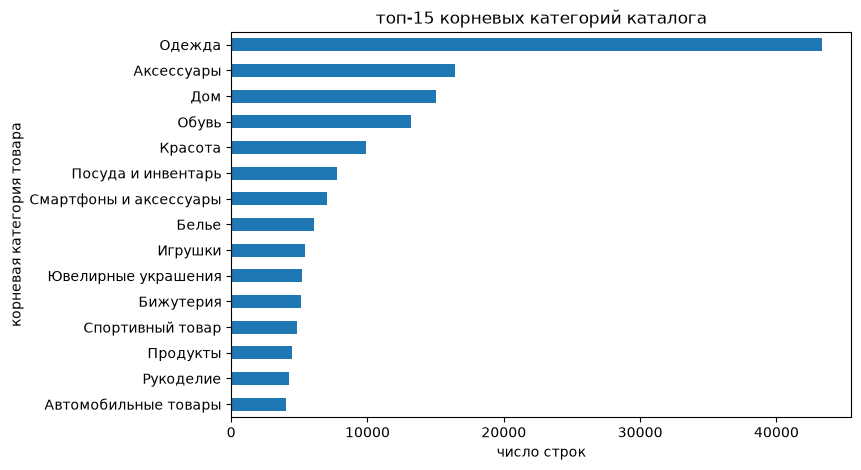

In [12]:
# корневые категории
root_counts = df_raw["subj_root_name"].value_counts()
print("корневых категорий:", len(root_counts))
print()
print(root_counts.head(15))

root_counts.head(15).sort_values().plot(kind="barh", figsize=(8, 5))
plt.title("топ-15 корневых категорий каталога")
plt.ylabel("корневая категория товара")
plt.xlabel("число строк")
plt.show()

In [13]:
# предметные категории
subj_counts = df_raw["subj_name"].value_counts()
print("всего предметных категорий:", len(subj_counts))
print("редких категорий с 1-2 строками:", (subj_counts <= 2).sum())
print()
print("самые частые:")
print(subj_counts.head(10))
print()
print("самые редкие:")
print(subj_counts.tail(10))

всего предметных категорий: 3234
редких категорий с 1-2 строками: 757

самые частые:
subj_name
Платья                         6998
Футболки                       5465
Сумки                          5215
Брюки                          3427
Чехлы для телефонов            3169
Постельное белье               2457
Блузки                         2342
Костюмы                        2317
Автомобильные ароматизаторы    2165
Туфли                          2159
Name: count, dtype: int64

самые редкие:
subj_name
Вилки поварские                         1
Сумки для сбора урожая                  1
Межпальцевые перегородки                1
Кронштейны для аудиотехники             1
DVD-плееры                              1
Ведерки детские                         1
Карнавальные парики                     1
Средства профилактики                   1
Гладильные системы                      1
Стиральные машины активаторного типа    1
Name: count, dtype: int64


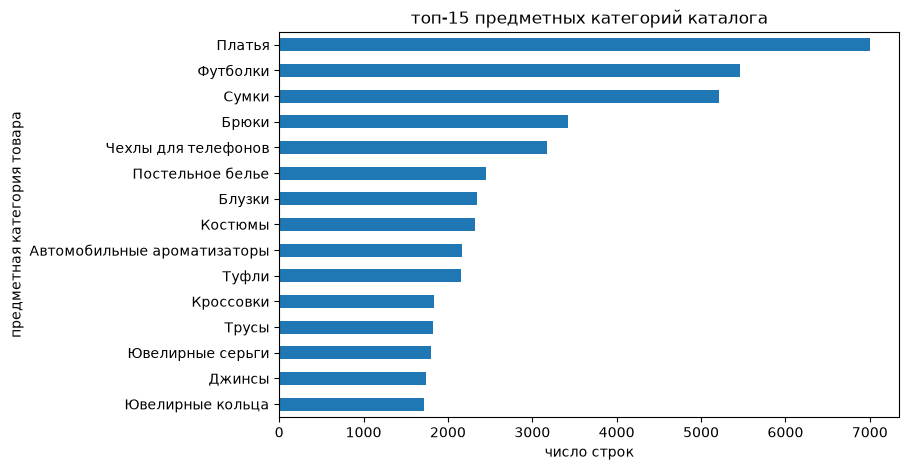

In [14]:
subj_counts.head(15).sort_values().plot(kind="barh", figsize=(8, 5))
plt.title("топ-15 предметных категорий каталога")
plt.ylabel("предметная категория товара")
plt.xlabel("число строк")
plt.show()

65 корневых категорий, топ 5 - одежда (43 тыс. строк), дальше аксессуары, дом, обувь и красота. 

Предметных категорий 3234, распределение с длинным хвостом: 757 категорий встречаются 1-2 раза. Самые частые - платья, футболки, сумки, брюки, чехлы для телефонов - распределение подкатегорий соответствует распределению корневых категорий товаров.

In [15]:
# к каким корневым категориям относятся размеченные товары в train и test
item_roots = df_raw[["imt_id", "subj_root_name"]].drop_duplicates("imt_id")
labeled_train = queries_train.merge(item_roots, left_on="item_id", right_on="imt_id", how="left")
labeled_test = queries_test.merge(item_roots, left_on="item_id", right_on="imt_id", how="left")

pd.DataFrame({
    "train": labeled_train["subj_root_name"].value_counts(),
    "test": labeled_test["subj_root_name"].value_counts(),
})

,train,test
subj_root_name,,
Одежда,8150,3458
Обувь,3303,1408


Все размеченные товары и в train, и в test относятся только к двум корневым категориям - одежда и обувь. Других категорий в разметке нет. Их и берём в работу, дальше анализ смотрим уже на них. Раз test размечен так же, можем фильтровать каталог без опасения убрать правильные ответы.

In [16]:
# выбранные категории
categories = ["Одежда", "Обувь"]
df_cat = df_raw[df_raw["subj_root_name"].isin(categories)]
print("строк в выбранных категориях:", len(df_cat))
print("карточек:", df_cat["imt_id"].nunique())

# карточки, у которых пусты и название, и описание
both_empty = (df_cat["imt_name"].str.strip() == "") & (df_cat["description"].str.strip() == "")
print("карточек без названия и описания:", df_cat.loc[both_empty, "imt_id"].nunique())
print("из них в пуле асессоров:", df_cat.loc[both_empty, "imt_id"].isin(df_dedup["imt_id"]).sum())

# пустые строки в выбранных категориях в сравнении со всем каталогом
pd.DataFrame({
    "весь каталог": (df_raw[text_cols].apply(lambda s: s.str.strip()) == "").mean(),
    "одежда и обувь": (df_cat[text_cols].apply(lambda s: s.str.strip()) == "").mean(),
}).round(3)

строк в выбранных категориях: 56503
карточек: 48489
карточек без названия и описания: 115
из них в пуле асессоров: 0


,весь каталог,одежда и обувь
imt_name,0.004,0.005
subj_name,0.000,0.000
subj_root_name,0.000,0.000
nm_colors_names,0.171,0.018
vendor_code,0.033,0.085
description,0.288,0.603
brand_name,0.001,0.001


В выбранных категориях 56 503 строки и 48 489 карточек. Пропуски здесь распределены иначе, чем по всему каталогу. Описаний не хватает ещё сильнее - пустые 60% строк (по всему каталогу 29%). Зато цвет почти всегда заполнен - пропусков всего 1.8% (по всему каталогу 17%), поэтому на него можно опираться в тексте карточки. Название и бренд заполнены почти всегда, как и во всём каталоге.

Пропуски в текстовых полях будем заполнять пустой строкой - это равносильно тому, что поля нет в тексте карточки. Подставлять выдуманные значения (заглушку вместо описания, самый частый цвет) не стали, чтобы не добавлять в текст ложную информацию. Удалять карточки без описания тоже нельзя - это 60% каталога. Удалим только карточки, у которых нет ни названия, ни описания: таких карточек 115, у них остаются только категория, бренд и цвет. Ни одна из них не входит в пул асессоров, так что на оценку это не повлияет. После дедупликации удалятся 113: у двух карточек есть и другая строка, где название заполнено, и при выборе строки с самым длинным описанием остаётся именно она.

<div class="alert alert-success">
<h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b> Очень сильный блок. Ты проверил, куда попадают размеченные товары, <b>отдельно для train и test</b>, и только после этого сузил каталог - выбор категорий опирается на данные, а не на «одежда самая большая». Отдельно порадовала проверка, что 115 карточек без текста не входят в пул асессоров, и сравнение долей пропусков до и после фильтрации: вывод «цвет в одежде заполнен почти всегда, на него можно опираться» - прямо готовое обоснование для шаблона текста.
</div>

<div class="alert alert-info">
<b>тут тоже добавил проверку пустых строк через .str.strip()</b> 
</div>

In [17]:
# чем отличаются строки одной карточки
multi = df_cat[df_cat["imt_id"].duplicated(keep=False)].groupby("imt_id")
print("карточек с несколькими строками:", multi.ngroups)
print("отличаются цветом:", (multi["nm_colors_names"].nunique() > 1).sum())
print("отличаются названием:", (multi["imt_name"].nunique() > 1).sum())
print("отличаются описанием:", (multi["description"].nunique() > 1).sum())

карточек с несколькими строками: 4338
отличаются цветом: 4221
отличаются названием: 220
отличаются описанием: 111


У 4338 карточек несколько строк, и почти всегда (4221) они отличаются только цветом. Название различается у 220 карточек, описание - всего у 111. Значит, при удалении дополнительных артикулов одной карточки в основном теряем различия в цвете товара.

<div class="alert alert-success">
<h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b> Этого шага в задании не было, и это здорово: ты посмотрел, <b>чем именно</b> отличаются строки одной карточки, и тем самым заранее обосновал правило дедупликации и честно зафиксировал его цену (теряем цвета других артикулов).
</div>

#### 2.4. Длина текстов

In [18]:
# длина названия и описания в символах и словах
lengths = pd.DataFrame({
    "название, символы": df_cat["imt_name"].str.len(),
    "название, слова": df_cat["imt_name"].str.split().str.len(),
    "описание, символы": df_cat["description"].str.len(),
    "описание, слова": df_cat["description"].str.split().str.len(),
})
lengths.describe(percentiles=[0.5, 0.9, 0.99]).round(0)

,"название, символы","название, слова","описание, символы","описание, слова"
count,56503.0,56503.0,56503.0,56503.0
mean,14.0,2.0,187.0,26.0
std,15.0,2.0,395.0,54.0
min,0.0,0.0,0.0,0.0
50%,8.0,1.0,0.0,0.0
90%,34.0,5.0,610.0,83.0
99%,80.0,10.0,1839.0,256.0
max,100.0,19.0,5000.0,704.0


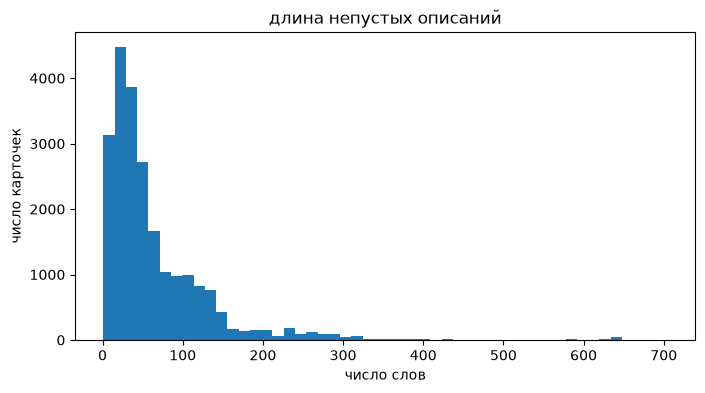

описаний длиннее 300 слов: 273
описаний ровно 5000 символов: 20


In [19]:
# распределение длины непустых описаний в словах
desc_words = lengths.loc[lengths["описание, слова"] > 0, "описание, слова"]

desc_words.plot(kind="hist", bins=50, figsize=(8, 4))
plt.title("длина непустых описаний")
plt.xlabel("число слов")
plt.ylabel("число карточек")
plt.show()

# выбросы: очень длинные описания и описания, упёршиеся в лимит 5000 символов
print("описаний длиннее 300 слов:", (desc_words > 300).sum())
print("описаний ровно 5000 символов:", (lengths["описание, символы"] == 5000).sum())

Названия очень короткие - медиана 1 слово, 90% названий не длиннее 5 слов. Непустые описания в основном до 100 слов, 99% - до 256 слов. Есть выбросы: 273 описания длиннее 300 слов и 20 описаний, обрезанных ровно на 5000 символах. Для эмбеддингов это важно: у большинства моделей лимит 512 токенов, самые длинные описания обрежутся. Длинный текст может размывать смысл, но таких карточек мало.

In [20]:
# самые частые названия
df_cat["imt_name"].value_counts().head(10)

imt_name
Платье       4692
Футболка     2949
Брюки        2164
Туфли        1451
Ботинки      1234
Блузка       1126
Рубашка      1119
Джинсы       1088
Кроссовки    1079
Юбка         1075
Name: count, dtype: int64

Самые частые названия - одно слово, совпадающее с категорией. По такому названию товары не различить, поэтому в текст карточки нужно добавлять описание, бренд и цвет.

<div class="alert alert-success">
<h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b> Длины посчитаны и в символах, и в словах, найдены описания, упёршиеся в лимит 5000 символов, - хорошая находка. Вывод про лимит токенов модели и про однословные названия, совпадающие с категорией, дальше напрямую используется при сборке <code>product_text</code>. Так и должно работать EDA.
</div>

#### 2.5. Качество текста

In [21]:
# смотрим 20 случайных карточек
df_cat.sample(20, random_state=SEED)[["imt_name", "subj_name", "brand_name", "nm_colors_names", "description"]]

,imt_name,subj_name,brand_name,nm_colors_names,description
85717,Сапоги,Сапоги,Vitacci,черный,
73576,Брюки,Брюки,KOTON,черный,
171326,Платье,Платья,Colambetta,"синий, белый",
67663,Кардиган,Кардиганы,Velvet Season,бежевый,"Важная информация! При заказе изделия, обращайте особое внимание на его параметры, указанные в таблице соответствия. Удлиненный кардиган прямого силуэта. Втачной рукав 7/8. V-образный вырез дополн..."
87795,Туфли,Туфли,МЫШОНОК,черный,
135770,Женские брюки,Брюки,MODERNFECI,бледно-розовый,
54495,Рубашка,Рубашки,DeFacto,голубой,
193603,Футболка,Футболки,ТВОЕ,темно-серый,
2606,Пальто,Пальто,Kling,"черный, красный, оранжевый",
30453,Босоножки,Босоножки,Buzoni,бежевый,


In [22]:
# ищем мусор в описаниях
desc = df_cat["description"]
print("html-теги:", desc.str.contains(r"<[a-zA-Z/][^>]*>").sum())
print("переносы строк:", desc.str.contains(r"[\r\n]").sum())
print("двойные пробелы:", desc.str.contains(r" {2,}").sum())
print("ссылки:", desc.str.contains(r"http|www\.").sum())

# шаблонные описания, которые повторяются у многих карточек
repeated = desc[desc != ""].value_counts()
print("описаний, повторяющихся 5+ раз:", (repeated >= 5).sum(), "- это", repeated[repeated >= 5].sum(), "строк")
repeated.head(5)

html-теги: 4
переносы строк: 2418
двойные пробелы: 2938
ссылки: 0
описаний, повторяющихся 5+ раз: 583 - это 5764 строк


description
Не спешите писать негативный отзыв при следующих ситуациях, независящих от нас: 1. Доставка задержалась или качество обслуживания в пункте выдачи не оправдало Ваших ожиданий. В данном случае напишите в техподдержку для оперативного решения. 2. Товар пришел поврежденным. Вы вправе отказаться от покупки и/или оформить возврат по браку. Товар спишут и утилизируют за наши средства, несмотря на вину доставщика/курьера, а Вам вернут денежные средства. 3. Пришел абсолютно другой товар. Пересортица товаров может происходить на складе. К сожалению, мы никак не можем повлиять на работу отдельных сотрудников марткеплейса, как бы этого не хотели. В данном случае необходимо оформить возврат, написать в техподдержку. С уважением, Ваш kari.    152
Легкая и практичная Российская одежда бренда "Линум" как правило из льна и шерсти, плотная, качественная ткань, выпущенная ограниченной партией. Одна, две вещи на размер. Подчеркивующаяя принадлежность к Русскому стилю. Вся серия, -набрать Валбе

Текст довольно чистый: html-тегов всего 4, ссылок нет. Но есть переносы строк (2418 описаний) и двойные пробелы (2938) - их убираем при очистке. 

Отдельная проблема - шаблонные описания: 583 текста повторяются 5+ раз (5764 строки). Часть из них вообще не про товар, например "Не спешите писать негативный отзыв..." или "Гарантийный срок товара 30 дней".

In [23]:
# артикулы внутри названий
name = df_cat["imt_name"]
vendor = df_cat["vendor_code"]

# артикул поставщика целиком внутри названия (короткие артикулы не считаем)
has_vendor = [len(v) >= 3 and v.lower() in n.lower() for n, v in zip(name, vendor)]
print("названий с vendor_code внутри:", sum(has_vendor))

# числа из 4+ цифр в названии
has_number = name.str.contains(r"\b\d{4,}\b")
print("названий с числом из 4+ цифр:", has_number.sum())

# есть ли цифры в запросах
query_texts = queries_train["query_text"].drop_duplicates()
print("запросов с цифрами:", query_texts.str.contains(r"\d").sum(), "из", len(query_texts))

name[has_number].head(10).to_list()

названий с vendor_code внутри: 100
названий с числом из 4+ цифр: 418
запросов с цифрами: 1 из 700


['Джинсы14274-8 на манжете',
 'Джинсы10416-17',
 'Джинсы10416-7',
 'Джинсы10427-2 с поясом',
 'Джинсы10433-4',
 'Джеггинсы1292-1',
 'Джеггинсы1292-2',
 'Джинсы2000-7',
 'Джинсы2011-7',
 'Джинсы2035']

Артикулы в названиях встречаются, но редко: vendor_code целиком есть в 100 названиях, числа из 4+ цифр - в 418 (меньше 1% карточек). В запросах цифр почти нет. Для поиска артикулы бесполезны, но и вредят слабо: это редкие слова, которые не совпадут ни с одним запросом. Удалять их не будем - правило "убрать слова с цифрами" заодно вырезало бы бренды (love2wait, TWENTY3) и размеры. Также видно, что артикул иногда приклеен к названию (Джинсы14274-8): тогда для TF-IDF слово "джинсы" в названии теряется. Если удалять такие артикулы - вместе с ними пропадают части названия, поэтому при очистке просто отделяем цифры от слова пробелом: "Джинсы14274-8" - "Джинсы 14274-8", так модель узнает название товара.

<div class="alert alert-success">
<h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b> Качество текста разобрано очень предметно: HTML, переносы, двойные пробелы, ссылки, а главное - шаблонные описания вроде «Не спешите писать негативный отзыв...». Решение по артикулам особенно понравилось: вместо грубого «удалить всё с цифрами» (которое срезало бы <code>love2wait</code> и <code>TWENTY3</code>) ты нашёл аккуратный альтернативный вариант - отделять цифры от приклеенного слова. Отличный пример решения, где учтены побочные эффекты.
</div>

#### 2.6. Бренд и цвет

In [24]:
print("уникальных брендов:", df_cat["brand_name"].nunique())

# берём первый цвет из списка и ищем его основу (первые 4 буквы) в названии
first_color = df_cat["nm_colors_names"].str.lower().str.split(",").str[0].str.strip()
name = df_cat["imt_name"].str.lower()
has_color = [c != "" and c[:4] in n for c, n in zip(first_color, name)]
print("доля карточек, где цвет упомянут в названии:", round(np.mean(has_color), 3))

уникальных брендов: 3916
доля карточек, где цвет упомянут в названии: 0.011


Брендов много - 3916. Пользователи часто ищут по бренду. Поэтому бренд добавляем в текст карточки. Цвет - базовая характеристика товара, без него не отличить одну футболку от другой. В одежде и обуви цвет заполнен почти всегда (пропусков 1.8%), но в названии упомянут только у 1% карточек - значит, в текст карточки его тоже нужно добавить.

<div class="alert alert-success">
<h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b> Бренд и цвет проанализированы с цифрами, а не «на глаз»: проверка, что цвет упомянут в названии всего у 1% карточек, - убедительный аргумент добавить его отдельным полем.
</div>

#### 2.7. Разметка

In [25]:
print("пар запрос-товар:", len(queries_train))
print("уникальных запросов:", queries_train["query_id"].nunique())
print("уникальных товаров:", queries_train["item_id"].nunique())
print("дублей пар запрос-товар:", queries_train.duplicated(["query_id", "item_id"]).sum())

# сколько оценённых товаров на один запрос
queries_train.groupby("query_id").size().describe()

пар запрос-товар: 11453
уникальных запросов: 700
уникальных товаров: 2285
дублей пар запрос-товар: 0


count    700.000000
mean      16.361429
std        5.424150
min        1.000000
25%       14.000000
50%       16.000000
75%       19.000000
max       31.000000
dtype: float64

В train 700 запросов и 11 453 пары запрос-товар, дублей пар нет. На запрос в среднем 16 оценённых товаров (от 1 до 31). Оценено 2285 разных товаров.

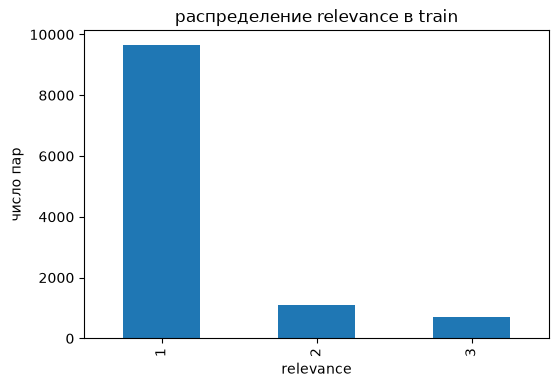

relevance
1    0.843
2    0.096
3    0.061
Name: proportion, dtype: float64

In [26]:
# распределение оценок релевантности
queries_train["relevance"].value_counts().sort_index().plot(kind="bar", figsize=(6, 4))
plt.title("распределение relevance в train")
plt.xlabel("relevance")
plt.ylabel("число пар")
plt.show()

queries_train["relevance"].value_counts(normalize=True).sort_index().round(3)

Классы сильно несбалансированы: 84% пар имеют оценку 1, 10% - оценку 2, 6% - оценку 3. Оценки 0 в разметке нет. Для бинарных метрик (Precision, Recall, MRR, HitRate) берём порог 2: релевантными считаем товары с оценкой 2 и 3, а товары с оценкой 1 (слабо подходят) и неразмеченные - нерелевантными. Иначе в релевантные попали бы 84% размеченных пар, и метрики не отличали бы точный поиск от приблизительного.

In [27]:
# сколько на запрос товаров с оценкой 3 и с оценкой >= 2
print("товаров с оценкой 3 на запрос:", queries_train[queries_train["relevance"] == 3].groupby("query_id").size().value_counts().to_dict())

rel_per_query = queries_train[queries_train["relevance"] >= 2].groupby("query_id").size()
print("запросов без товаров с оценкой >= 2:", queries_train["query_id"].nunique() - len(rel_per_query))
print()
print(rel_per_query.describe())

товаров с оценкой 3 на запрос: {1: 700}
запросов без товаров с оценкой >= 2: 0

count    700.000000
mean       2.572857
std        2.465001
min        1.000000
25%        1.000000
50%        1.000000
75%        3.000000
max       17.000000
dtype: float64


У каждого запроса ровно один товар с оценкой 3 и в среднем 2.6 товара с оценкой >= 2 (у половины запросов - всего один). Поэтому даже идеальный поиск не сможет заполнить топ-10 подходящими товарами: в выдаче неизбежно будут нерелевантные. Это важно помнить, когда будем смотреть на precision - низкое значение будет нормой. 

У всех 700 запросов есть минимум один товар с оценкой 2 или 3.

<div class="alert alert-success">
<h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b> Анализ разметки выполнен отлично: заметил, что оценки 0 нет вовсе, что у каждого запроса ровно один товар с оценкой 3, и заранее сделал вывод, что низкий precision будет нормой. Порог 2 обоснован данными (84% пар с оценкой 1). Это то понимание, которое потом защищает от неверной интерпретации метрик.
</div>

#### 2.8. Запросы

In [28]:
# примеры запросов
queries_train.drop_duplicates("query_id").sample(15, random_state=SEED)["query_text"].to_list()

['топы cop copine',
 'худи mego as',
 'бриджи зуавы',
 'кожаные мокасины',
 'кожаные сабо с открытым мысом',
 'классические джинсовые джинсы',
 'шубы натуральные на пуговицах',
 'тапочки asd',
 'тапочки t taccardi',
 'кигуруми londe',
 'джеггинсы утягивающие',
 'дышащий дутики',
 'мужские резиновые сапоги',
 'прямые жакеты',
 'пальто crockid']

In [29]:
# длина запросов в словах
queries_train.drop_duplicates("query_id")["query_text"].str.split().str.len().describe()

count    700.000000
mean       2.704286
std        0.896494
min        2.000000
25%        2.000000
50%        2.000000
75%        3.000000
max        7.000000
Name: query_text, dtype: float64

Запросы короткие - 2-3 слова (максимум 7), написаны в пользовательском стиле: тип товара плюс признак, бренд или материал ("кожаные мокасины", "пальто crockid"). Часто содержат слова из карточки (категорию, бренд), поэтому лексический поиск на них может работать неплохо.

#### 2.9. Шаблон текста товара

Рассмотрел три варианта единого текста товара product_text:

**Вариант А: `subj_name + imt_name`.** Короткий текст, только суть товара. Но название в большинстве карточек - одно слово, совпадающее с категорией ("Платье", "Футболка"), поэтому тексты тысяч карточек будут одинаковыми и поиск не сможет их различить.

**Вариант Б: `subj_name + imt_name + nm_colors_names + description`.** Добавляются детали из описания и цвет. Цвет в одежде и обуви заполнен почти всегда (пропусков 1.8%), а в названии упомянут только у 1% карточек, поэтому его нужно добавлять отдельно - это не дублирование. Минусы: описание пустое у 60% карточек, длинные описания (273 длиннее 300 слов) могут размыть смысл, а часть описаний - шаблонный текст, не относящийся к товару ("Не спешите писать негативный отзыв...").

**Вариант В: вариант Б + `brand_name`.** Пользователи ищут по бренду ("пальто crockid", "тапочки t taccardi"), и для лексического поиска точное совпадение бренда полезно. Но бренд - это идентификатор, а не смысловая характеристика, и для эмбеддингов он может оказаться шумом.

**Выбор:** для базового пайплайна берём вариант В - он содержит всю информацию о товаре. Категорию ставим первой, потому что название часто просто повторяет её или пустое. На неделе 3 проверим экспериментом, помогает ли бренд семантическому поиску или мешает (вариант Б против варианта В).

#### Выводы по EDA

Каталог - 200 000 строк, 174 427 карточек, 65 корневых категорий. Разметка - 700 запросов в train и 300 в test, по 16 оценённых товаров на запрос, пересечений между train и test нет. Все размеченные товары - только из одежды и обуви. Запросы короткие (2-3 слова) и часто содержат категорию и бренд из карточки, поэтому лексический baseline может оказаться сильным.

**Принятые решения**

1. Уровень индекса - карточка imt_id: разметка сделана по карточкам. Оставляем одну строку на карточку - с самым длинным описанием, а при равной длине с наименьшим nm_id, чтобы выбор не зависел от порядка строк. Строки одной карточки почти всегда отличаются только цветом.
2. Категории - "Одежда" и "Обувь": все размеченные товары train и test только из них. В работе 48 489 карточек.
3. Пропуски в текстовых полях заполняем пустой строкой - поле просто не попадает в текст. Карточки без описания (60%) не удаляем. Удаляем только карточки, где нет ни названия, ни описания: после дедупликации их 113, ни одна не входит в пул асессоров.
4. Шаблон product_text - категория + название + бренд + цвет + описание (вариант В). Поможет ли бренд семантическому поиску - проверим на неделе 3.
5. Порог релевантности - 2: оценка 1 означает, что товар подходит слабо. Порог стоит подтвердить у заказчика.
6. Каталог оценки - только карточки из пула асессоров, иначе неразмеченные товары занизят метрики.

**Проблемы в данных, которые учитываем при очистке**

1. Пропуски закодированы пустыми строками, а не NaN - isna() их не видит.
2. Переносы строк (2418 описаний) и двойные пробелы (2938) - заменяем одним пробелом.
3. HTML-теги - единичные (4), но убираем.
4. Артикулы, приклеенные к словам ("Джинсы14274-8") - отделяем цифры пробелом.
5. Шаблонные описания: 583 текста повторяются у 5764 строк, часть из них вообще не про товар ("Не спешите писать негативный отзыв...") - пока оставляем, их чистка - кандидат на эксперимент.
6. Длинные описания: 273 длиннее 300 слов, 20 обрезаны на 5000 символах - могут не поместиться в лимит модели эмбеддингов.
7. При дедупликации теряются цвета других артикулов карточки.
8. 43 артикула nm_id встречаются дважды (две версии одной карточки) - уходят при дедупликации.
9. У половины запросов всего один релевантный товар - precision будет низким даже у хорошего поиска.

<div class="alert alert-success">
<h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b> Три варианта шаблона с плюсами и минусами, выбор со ссылкой на наблюдения EDA и заранее запланированный эксперимент «Б против В» - ровно то, что ожидается. Итоговый список решений и проблем данных оформлен очень удобно, к нему легко вернуться. Кстати, твоё решение включить бренд в текст - вполне законная альтернатива варианту без бренда, и дальше видно, насколько сильно оно усиливает лексический поиск.
</div>

---

## Неделя 2 — базовый пайплайн и оценка качества

**Цель:** оперевшись на результаты EDA, создать работающий поиск и получить первые метрики качества.

Прежде чем реализовывать семантический поиск, основанный на эмбеддингах, нужно проверить, как справляется более простая модель, опирающаяся на TF-IDF. Простая модель нужна как baseline, без этой точки отсчёта результат невозможно интерпретировать.


### 1. Подготовка данных


Реализуйте решения недели 1:

1. Отфильтруйте выбранные категории.
2. Дедуплицируйте строки по `imt_id`. Сформулируйте правило, по которому будете определять, какую строку оставить. К примеру, можете оставить строку с самым информативным описанием. Ответ обоснуйте.
3. Отбросьте карточки, у которых пусты одновременно и `imt_name`, и `description`.
4. Напишите функцию очистки текста.
5. Соберите единый текст карточек в отдельной колонке `product_text`.

In [30]:
# размеченные товары train и test - после каждого шага проверяем, что они на месте
labeled_items = pd.concat([queries_train["item_id"], queries_test["item_id"]]).unique()

# оставляем выбранные категории
df_products = df_raw[df_raw["subj_root_name"].isin(categories)].copy()
assert pd.Series(labeled_items).isin(df_products["imt_id"]).all(), "после фильтра категорий потерялись размеченные товары"

# дедупликация по imt_id: оставляем строку с самым длинным описанием,
# при равной длине - строку с наименьшим nm_id
# добавим колонку длины описания, отсортируем по ней и nm_id, после drop_duplicates, удаляем
df_products["desc_len"] = df_products["description"].str.len()
df_products = df_products.sort_values(["desc_len", "nm_id"], ascending=[False, True], kind="stable")
df_products = df_products.drop_duplicates("imt_id").drop(columns="desc_len")
assert pd.Series(labeled_items).isin(df_products["imt_id"]).all(), "после дедупликации потерялись размеченные товары"

# отбрасываем карточки, у которых пусты и название, и описание
empty_name = df_products["imt_name"].str.strip() == ""
empty_desc = df_products["description"].str.strip() == ""
df_products = df_products[~(empty_name & empty_desc)].reset_index(drop=True)
assert pd.Series(labeled_items).isin(df_products["imt_id"]).all(), "после отсева пустых карточек потерялись размеченные товары"

print("карточек после подготовки:", len(df_products))

карточек после подготовки: 48376


В EDA видно, что строки одной карточки почти всегда отличаются только цветом, а описание у них обычно одинаковое. Поэтому оставляем строку с самым длинным описанием и наименьшим nm_id - в ней больше всего информации о товаре. Карточки без названия и описания удаляем.

<div class="alert alert-warning">
    <h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>
    
<b>Небольшие замечания и рекомендации💡:</b> Правило дедупликации обосновано хорошо. Но обрати внимание на воспроизводимость: у 60% карточек описание пустое, то есть у множества строк одинаковая «длина», а <code>sort_values</code> по умолчанию использует нестабильную сортировку. При другом порядке строк на входе может остаться другой артикул карточки (с другим цветом). Подумай, как сделать выбор строки однозначным.
</div>

<div class="alert alert-info">
<b>тут тоже добавил проверку пустых строк через .str.strip()</b> 
</div>

<div class="alert alert-info">
<b>дедупликацию поправил - теперь сортировка идёт по двум ключам, kind="stable" - оставляем порядок среди равных, остаётся строка с самым длинным описанием, а при равной длине с наименьшим nm_id</b> 
</div>

<div class="alert alert-warning">
    <h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>
    
<b>Небольшие замечания и рекомендации💡:</b> После каждого шага фильтрации (категории, дедупликация, отсев пустых) полезно явно проверять, что размеченные товары <b>train и test</b> не потерялись, - например, через <code>assert</code>. Сейчас такая проверка есть только позже и только для train.
</div>

<div class="alert alert-info">
<b>добавил ассерты после каждого шага, если вдруг что-то пойдёт не так, оставимся тут и будем знать на каком шаге потерялись нужные карточки</b> 
</div>

In [31]:
# функция очистки текста
def clean_text(text):
    text = re.sub(r"<[^>]+>", " ", text) # html теги
    text = re.sub(r"[^\w\s.,:;!?%()/-]", " ", text)  # спецсимволы
    text = re.sub(r"([а-яё])(\d)", r"\1 \2", text, flags=re.IGNORECASE)  # отделяем цифры от слова: джинсы1010 - джинсы 1010
    text = re.sub(r"\s+", " ", text) # переносы строк и лишние пробелы
    return text.strip()


# проверяем на примере
clean_text("Джинсы14274-8 <b>летние</b> ★★★\n\nхлопок  100%")

'Джинсы 14274-8 летние хлопок 100%'

In [32]:
# чистим текстовые поля
for col in ["imt_name", "subj_name", "brand_name", "nm_colors_names", "description"]:
    df_products[col] = df_products[col].apply(clean_text)

In [33]:
# собираем единый текст карточки: категория, название, бренд, цвет, описание
# пустые поля пропускаем, иначе в тексте останутся висящие точки, между которых пробел
text_fields = ["subj_name", "imt_name", "brand_name", "nm_colors_names", "description"]
df_products["product_text"] = df_products[text_fields].apply(
    lambda row: ". ".join(value for value in row if value.strip()), axis=1
)

# проверяем на карточке с пустым брендом
empty_brand = df_products["brand_name"].str.strip() == ""
df_products.loc[empty_brand, ["product_text"]].head()

,product_text
11501,"Пиджаки. Пиджак мужской блейзер. серый, черный. Пиджак Slim fit. Внутреняя отделка пиджака выполнена в полуподкладе. Плечо мягкое. Имеет узкий крой с плотной посадкой по фигуре. Пиджак на 2 пугови..."
12240,Рубашки. Рубашка мужская классическая. голубой. Классическая сорочка Regular fit в клетку с коротким рукавом. Имеет полуприталнный крой (практически прямой) со свободной посадкой по фигуре. Модель...
12318,"Костюмы. Костюм мужской двойка/классический. синий. Классический костюм Slim fit. Имеет узкий крой с плотной посадкой по фигуре. Пиджак на 2 пуговицах, 1 шлица, имеет 2 боковых, нагрудный и 3 внут..."
12319,"Костюмы. Костюм мужской двойка. голубой, светло-синий, синий, бежевый. Классический костюм Slim fit. Имеет узкий крой с плотной посадкой по фигуре. Пиджак на 2 пуговицах, 1 шлица, имеет 2 боковых,..."
12320,"Костюмы. Костюм мужской двойка. серый. Классический костюм Slim fit. Имеет узкий крой с плотной посадкой по фигуре. Пиджак на 2 пуговицах, 1 шлица, имеет 2 боковых, нагрудный и 3 внутренних карман..."


product_text собираем по варианту В: категория, название, бренд, цвет, описание. Категория идёт первой, потому что название часто просто повторяет её или совсем пустое. Поля разделяем точкой, чтобы для модели эмбеддингов они были отдельными фактами о товаре, а не одной слипшейся фразой.

<div class="alert alert-success">
<h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b> Функция очистки закрывает именно те проблемы, которые ты нашёл в EDA, и сразу проверена на показательном примере - это хорошая практика. Порядок полей и разделитель-точка аргументированы.
</div>

<div class="alert alert-block alert-danger">
<h2> Комментарий ревьюера v1<a class="tocSkip"></h2>

<b>На доработку🤔:</b> Посмотри, что получится в <code>product_text</code>, если у карточки пустое название, бренд или цвет (а пустой цвет или бренд у тебя встречаются). Сейчас поля склеиваются безусловно, поэтому в тексте появятся «висящие» разделители. Пустые поля нужно пропускать при сборке текста. Проверь результат на карточках с пустыми полями.
</div>

<div class="alert alert-info">
<b>проверил - остались пробелы между точками. сейчас склеиваем только непустые if value.strip() через точку с пробелом + добавил проверку как раз строк с пустым брендом</b> 
</div>

### Каталог для поиска и оценки

1. Посчитайте метрику при поиске по всему отфильтрованному каталогу. Например, вычислите NDCG@10 лексическим поиском на 100 запросах.
2. Выведите топ-10 для одного запроса и отметьте, какие товары есть в разметке, а каких нет. Выясните, в чём проблема.
3. Ограничьте каталог оценки пулом асессоров: возьмите из `wb_products_dedup.parquet` только список `imt_id` и оставьте в своём подготовленном каталоге пересечение с ним. Тексты и все признаки — ваши, из шага 1.
4. Пересчитайте метрику и сравните результаты.
5. Посмотрите на распределение `relevance` и число оценённых товаров на запрос. Проверьте, у всех ли запросов есть товары с `relevance` ≥ 2.

In [34]:
# ndcg при поиске по всему каталогу

# возвращает imt_id 10 товаров, больше всего похожих на запрос
def lexical_top(query, vectorizer, matrix, catalog, top_k=10):
    query_vec = vectorizer.transform([clean_text(query)])  # запрос чистим так же, как тексты товаров
    scores = (matrix @ query_vec.T).toarray().ravel()  # сравниваем векторы
    # по убыванию score, при равных score - по imt_id, чтобы порядок не менялся между запусками
    top = np.lexsort((catalog["imt_id"].to_numpy(), -scores))[:top_k]              
    return catalog["imt_id"].iloc[top].to_list() # достаём imt_id


# ndcg по полной шкале оценок
def ndcg_at_k(recs, rel, k=10):
    # recs - найденные товары по порядку, rel - словарь {товар: оценка}

    # dcg - насколько хороша наша выдача
    dcg = 0.0
    for pos, i in enumerate(recs[:k], start=1):
        gain = 2 ** rel.get(i, 0) - 1  # вес товара - добавляем релевантным больше веса
        dcg += gain / np.log2(pos + 1)  # чем ниже место, тем меньше вклад

    # dcg идеальной выдачи - лучшие товары из разметки стоят на первых местах
    idcg = 0.0
    ideal = sorted(rel.values(), reverse=True)[:k]  # оценки по убыванию
    for pos, r in enumerate(ideal, start=1):
        idcg += (2 ** r - 1) / np.log2(pos + 1)

    # доля от идеала
    if idcg > 0:
        return dcg / idcg
    return 0.0


# средний ndcg по 100 запросам
def mean_ndcg(vectorizer, matrix, catalog):
    scores = []
    for query_id in sample_queries:
        rows = queries_train[queries_train["query_id"] == query_id]  # берём только этот запрос
        query_text = rows["query_text"].iloc[0]  # текст этого запроса
        rel = dict(zip(rows["item_id"], rows["relevance"]))  # словарь {товар: оценка}
        found = lexical_top(query_text, vectorizer, matrix, catalog) # ищем похожие
        scores.append(ndcg_at_k(found, rel)) # считаем метрику
    return np.mean(scores) # усредняем


# 100 случайных запросов
sample_queries = queries_train["query_id"].drop_duplicates().sample(100, random_state=SEED)

# tfidf векторы всех товаров каталога
vectorizer_full = TfidfVectorizer()
matrix_full = vectorizer_full.fit_transform(df_products["product_text"])

ndcg_full = mean_ndcg(vectorizer_full, matrix_full, df_products)
print("ndcg@10, весь каталог:", round(ndcg_full, 3))

ndcg@10, весь каталог: 0.064


In [35]:
# топ 10 для одного запроса - какие товары есть в разметке, а каких нет

query_id = sample_queries.iloc[0]  # берём первый запрос из наших 100
rows = queries_train[queries_train["query_id"] == query_id]  # разметка этого запроса
query_text = rows["query_text"].iloc[0]  # текст запроса
rel = dict(zip(rows["item_id"], rows["relevance"]))  # словарь {товар: оценка}
print("запрос:", query_text)

# ищем 10 товаров по всему каталогу
found = lexical_top(query_text, vectorizer_full, matrix_full, df_products)

# таблица найденных товаров в том же порядке, что выдал поиск
top = df_products.set_index("imt_id").loc[found, ["imt_name", "subj_name", "brand_name"]]

# для каждого найденного товара - его оценка, или "нет в разметке", если асессоры его не оценивали
top["оценка в разметке"] = [rel.get(i, "нет в разметке") for i in found]
top

запрос: топы cop copine


,imt_name,subj_name,brand_name,оценка в разметке
imt_id,,,,
10067786,Топы,Топы,KOTON,нет в разметке
10022264,Топ,Топы,Cop.Copine,нет в разметке
10022253,Топ,Топы,Cop.Copine,нет в разметке
10048067,Футболка,Топы,D F,нет в разметке
10022252,Топ,Топы,Cop.Copine,3
10074565,Топы,Топы,Fantosh,нет в разметке
10074564,Топы,Топы,Fantosh,нет в разметке
10133186,Топы,Топы,cherryfifa,нет в разметке
10133188,Топы,Топы,cherryfifa,нет в разметке


При поиске по всему каталогу NDCG@10 всего 0.064. На примере видно почему - на запрос "топы cop copine" поиск нашёл сразу несколько топов Cop.Copine, но в разметке из них есть только один. ещё 2 - такие же подходящие товары, но асессоры их не оценивали, и метрика засчитывает их как ошибку. В полном каталоге 48 тысяч карточек, а размечено 16 на запрос, поэтому выдача почти целиком состоит из неразмеченных товаров, и метрика показывает неполноту разметки, а не качество поиска.

<div class="alert alert-success">
<h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b> Очень хорошо: метрика на полном каталоге посчитана, пример топ-10 разобран, и ты точно сформулировал суть проблемы - неполнота пулированной разметки, а не плохой поиск. Пример с Cop.Copine, где подходящие, но неоценённые товары засчитываются как ошибка, - отличная иллюстрация.
</div>

In [36]:
# каталог оценки: только карточки из пула асессоров
pool_ids = df_dedup["imt_id"]
df_eval = df_products[df_products["imt_id"].isin(pool_ids)].reset_index(drop=True) # берём только перечение

print("полный каталог:", len(df_products))
print("каталог оценки:", len(df_eval))
print("доля товаров train, найденных в каталоге оценки:", queries_train["item_id"].isin(df_eval["imt_id"]).mean())

полный каталог: 48376
каталог оценки: 4256
доля товаров train, найденных в каталоге оценки: 1.0


После подготовки в полном каталоге 48 376 карточек, в каталоге оценки - 4256. все товары из train есть в каталоге оценки.

In [37]:
# ndcg@10 при поиске только по каталогу оценки (пул асессоров)
vectorizer_eval = TfidfVectorizer()
matrix_eval = vectorizer_eval.fit_transform(df_eval["product_text"])

ndcg_eval = mean_ndcg(vectorizer_eval, matrix_eval, df_eval)
print("ndcg@10, весь каталог:", round(ndcg_full, 3))
print("ndcg@10, каталог оценки:", round(ndcg_eval, 3))

ndcg@10, весь каталог: 0.064
ndcg@10, каталог оценки: 0.516


На каталоге оценки NDCG@10 вырос с 0.064 до 0.516 хотя поиск тот же самый. Значит, дальше все метрики считаем только на каталоге оценки: там в выдаче в основном оценённые товары, и метрика отражает качество поиска, а не полноту разметки.

<div class="alert alert-success">
<h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b> Каталог оценки ограничен пулом асессоров, тексты и признаки - свои из шага 1, рост NDCG с 0.063 до 0.513 при том же поиске объяснён правильно.
</div>

Распределение `relevance`, число оценённых товаров на запрос и проверку, что у каждого запроса есть товар с оценкой >= 2, сделали в EDA (раздел 2.7).

### 2. Модели поиска

Реализуйте два поисковых движка с одинаковым интерфейсом. Это позволит прогнать оба через одну функцию оценки:


Реализуйте лексический baseline на TF-IDF:

In [38]:
# лексический поиск по каталогу оценки
# векторы товаров уже посчитаны vectorizer_eval и matrix_eval
def search_lexical(query, top_k=10):
    query_vec = vectorizer_eval.transform([clean_text(query)])  # запрос чистим так же, как тексты товаров
    scores = (matrix_eval @ query_vec.T).toarray().ravel()  # сравниваем векторы
    # по убыванию score, при равных score - по imt_id, чтобы порядок не менялся между запусками
    top = np.lexsort((df_eval["imt_id"].to_numpy(), -scores))[:top_k]
    result = df_eval.iloc[top][["imt_id", "imt_name", "subj_name", "brand_name", "nm_colors_names"]].copy() # достаём информацию
    result["score"] = scores[top]
    return result

# проверим
search_lexical("белые футболки")

,imt_id,imt_name,subj_name,brand_name,nm_colors_names,score
3595,10025623,Брюки белые,Брюки,PLEASE,белый,0.398020
3337,101151,Футболки,Футболки,Pezzo,черный,0.300749
1749,10099430,Шорты джинсовые светлые,Шорты,Artibisi,белый,0.259976
3290,10152604,Брюки-кюлоты,Брюки,Concept Club,белый,0.252773
597,10083732,Футболка женская серая,Футболки,Shelter,серый,0.238817
3127,10029326,Шорты джинсовые,Шорты,FoWay,белый,0.215057
3065,10126855,Футболка женская/Футболки/Футболки женские/одежда,Футболки,MALKOVICH,"серый меланж, голубой",0.202207
3851,10085058,Футболки-поло,Футболки-поло,JODEEN,серый,0.196603
108,10117760,футболка,Футболки,Libefolle,белый,0.193338
104,10117761,футболка,Футболки,Libefolle,темно-синий,0.193018


<div class="alert alert-block alert-danger">
<h2> Комментарий ревьюера v1<a class="tocSkip"></h2>

<b>На доработку🤔:</b> Запрос должен проходить ту же обработку, что и тексты товаров. Сейчас <code>product_text</code> прошёл через <code>clean_text</code>, а запрос подаётся в векторизатор как есть - это касается и лексического, и семантического поиска. Приведи обработку к единообразию.
</div>

<div class="alert alert-info">
<b>да, видел это даже в подсказках, почему-то не выписал в требования и в итоге забыл применить. исправил - теперь запрос проходит через clean_text перед векторизацией - и в лексическом поиске, и в семантическом, и в функции lexical_top</b> 
</div>

<div class="alert alert-warning">
    <h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>
    
<b>Небольшие замечания и рекомендации💡:</b> Посмотри на выдачу по «удобные кроссовки для бега» ниже: у многих карточек одинаковый score. В таком случае порядок внутри <code>argsort</code> ничем не определён, и метрики могут немного «плавать» от запуска к запуску. Стоит добавить детерминированный tie-break (например, по <code>imt_id</code>).
</div>

<div class="alert alert-info">
<b>добавил сортировку по двум ключам lexsort - главный score, а при равных значениях порядок задаёт imt_id по возрастанию</b> 
</div>

Реализуйте семантический поиск:

In [39]:
# мультиязычная модель эмбеддингов с поддержкой русского
model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

# эмбеддинги всех товаров каталога оценки, считаем батчами по 64 текста
# normalize_embeddings=True - длина каждого вектора 1, тогда скалярное произведение = косинусная близость
item_embeddings = model.encode(df_eval["product_text"].to_list(), batch_size=64, normalize_embeddings=True)
print("эмбеддинги товаров:", item_embeddings.shape)


# семантический поиск: ищем товары, чьи эмбеддинги ближе всего к эмбеддингу запроса
def search_semantic(query, top_k=10):
    query_emb = model.encode([clean_text(query)], normalize_embeddings=True)[0]  # запрос чистим так же, как тексты товаров
    scores = item_embeddings @ query_emb  # косинусная близость к каждому товару
    # по убыванию score, при равных score - по imt_id, чтобы порядок не менялся между запусками
    top = np.lexsort((df_eval["imt_id"].to_numpy(), -scores))[:top_k]
    result = df_eval.iloc[top][["imt_id", "imt_name", "subj_name", "brand_name", "nm_colors_names"]].copy() # достаём информацию
    result["score"] = scores[top]
    return result


search_semantic("белые футболки")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

эмбеддинги товаров: (4256, 384)


,imt_id,imt_name,subj_name,brand_name,nm_colors_names,score
3321,100573,Футболка,Футболки,SELA,белый,0.806854
4000,10119318,Футболка Миньоны,Футболки,ТВОЕ,белый,0.763540
3197,10141607,Футболка детская для девочек/нарядная,Футболки,pop.e,белый,0.717688
4217,10174921,Платье-рубашка,Платья,LIDO,"белый, голубой",0.715391
4162,10163637,Футболка Матрица,Футболки,LEMONBROTHERS,белый,0.710774
75,10134079,Футболка с принтом,Футболки,MEGO AS,белый,0.700698
3528,10012622,Футболка Simply,Футболки,CLABIN,белый,0.698633
3595,10025623,Брюки белые,Брюки,PLEASE,белый,0.695038
4245,10070813,Футболка - EUDOR,Футболки,MANGO MAN,белый,0.682099
3447,10000655,Футболка DASHAEV Stamp,Футболки,DASHAEV,белый,0.677837


Модель paraphrase-multilingual-MiniLM-L12-v2 выбрал как простую и быструю модель с поддержкой русского. она небольшая и считает эмбеддинги каталога на обычном процессоре примерно за минуту. Ограничение модели - она читает только первые 128 токенов текста, поэтому у длинных описаний конец обрезается. Для базового решения решил, что это допустимо - самое важное (категория, название, бренд, цвет) стоит в начале product_text.

<div class="alert alert-success">
<h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b> Семантический поиск реализован правильно: одна модель для запроса и товаров, эмбеддинги нормализованы и посчитаны батчами, скалярное произведение = косинус. Выбор модели обоснован, и отдельно отмечу, что ты знаешь <b>реальный</b> лимит этой модели (128 токенов, а не «обычные» 512) и учёл его в порядке полей.
</div>

Прогоните 3–5 запросов вручную и сравните выдачу обоих подходов. Это самый простой способ поймать грубые ошибки до подсчёта метрик.

In [40]:
# сравниваем выдачу двух подходов на нескольких запросах
manual_queries = ["белые футболки", "удобные кроссовки для бега", "платье на выпускной", "теплая обувь на зиму"]

for query in manual_queries:
    print("=="*20)
    print("запрос:", query)
    print("лексический поиск:")
    print(search_lexical(query, top_k=5).to_string(index=False))
    print("семантический поиск:")
    print(search_semantic(query, top_k=5).to_string(index=False))
    print()

запрос: белые футболки
лексический поиск:
  imt_id                imt_name subj_name   brand_name nm_colors_names    score
10025623             Брюки белые     Брюки       PLEASE           белый 0.398020
  101151                Футболки  Футболки        Pezzo          черный 0.300749
10099430 Шорты джинсовые светлые     Шорты     Artibisi           белый 0.259976
10152604            Брюки-кюлоты     Брюки Concept Club           белый 0.252773
10083732  Футболка женская серая  Футболки      Shelter           серый 0.238817
семантический поиск:
  imt_id                              imt_name subj_name    brand_name nm_colors_names    score
  100573                              Футболка  Футболки          SELA           белый 0.806854
10119318                      Футболка Миньоны  Футболки          ТВОЕ           белый 0.763540
10141607 Футболка детская для девочек/нарядная  Футболки         pop.e           белый 0.717688
10174921                        Платье-рубашка    Платья          L

Грубые ошибки есть у обоих подходов, но разные:

- белые футболки - лексический поиск ставит первыми белые брюки и шорты: совпало слово белые, а тип товара нет. Семантический возвращает футболки, в основном белые, есть одно платье - рубашка, но тоже белая.
- удобные кроссовки для бега - лексический находит кроссовки по точному слову. Семантический ставит выше кроссовок кеды и туфли на каблуке - путает категории обуви.
- платье на выпускной - семантический понимает смысл и находит нарядные платья, но в топ попадает крестильное платье. Лексический находит просто платья и сарафан.
- теплая обувь на зиму - лексический выдаёт кроссовки на лето и футболку: в запросе нет слов, которые точно совпали бы с зимней обувью. Семантический находит угги и зимние ботинки.

Лексический поиск ошибается, когда совпадает не главное слово запроса (цвет вместо типа товара) или когда нужных слов в карточках нет. Семантический лучше понимает запросы по назначению (на выпускной, на зиму), но путает похожие категории.

<div class="alert alert-success">
<h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b> Ручная проверка на запросах разного типа (точный тип товара, назначение, повод, сезон) и разбор ошибок обоих подходов - очень хороший. Честное замечание «белые ли они - по выводу не видно» говорит о критичном отношении к собственным результатам.
</div>

<div class="alert alert-warning">
    <h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>
    
<b>Небольшие замечания и рекомендации💡:</b> Раз цвет не виден - просто добавь в вывод функций поиска <code>nm_colors_names</code> и <code>brand_name</code>. Для ручного анализа это сильно упростит жизнь.
</div>

<div class="alert alert-info">
<b>да, так проще. спасибо. хотя вроде бы очевидное решение же)</b> 
</div>

### 3. Оценка качества решений

Реализуйте метрики Precision@K, Recall@K, MRR, NDCG@K, HitRate@K.

Три ключевые особенности, которые надо учесть при расчёте:

1. Порог бинаризации. Precision@K, Recall@K, MRR, HitRate@K бинарны, а шкала `relevance` — от `0` до `3`. С какой оценки товар считается релевантным? Вынесите порог в параметр, а не константу внутри функции.
2. NDCG считайте по полной шкале 0–3 (`gain = 2^rel - 1`), а не по бинаризованной, иначе теряется смысл градуированной разметки.
3. Неразмеченные товары в выдаче трактуйте как нерелевантные (`relevance_map.get(item_id, 0)`).

Выводы запишите в Markdown-ячейке и рабочем файле Markdown.

In [41]:
RELEVANCE_THRESHOLD = 2   # релевантными считаем товары с оценкой 2 и 3, обоснование - в EDA (раздел 2.7)


# доля релевантных товаров в топ-k
def precision_at_k(recs, relevant, k):
    hits = sum(1 for i in recs[:k] if i in relevant)
    return hits / k


# доля найденных релевантных товаров из всех релевантных
def recall_at_k(recs, relevant, k):
    hits = sum(1 for i in recs[:k] if i in relevant)
    return hits / len(relevant)


# 1, если в топ-k есть хотя бы один релевантный товар, иначе 0
def hitrate_at_k(recs, relevant, k):
    for i in recs[:k]:
        if i in relevant:
            return 1.0
    return 0.0


# 1 / место первого релевантного товара в выдаче
def mrr(recs, relevant):
    for pos, i in enumerate(recs, start=1):
        if i in relevant:
            return 1.0 / pos
    return 0.0

In [42]:
# считаем метрики поиска по каждому запросу разметки
# threshold - порог бинаризации, k_list - значения K, для которых считаем метрики
def evaluate(search_func, queries, threshold=RELEVANCE_THRESHOLD, k_list=(1, 3, 5, 10)):
    rows = []
    for query_id, group in queries.groupby("query_id"):  # group - строки разметки одного запроса
        query_text = group["query_text"].iloc[0]
        rel = dict(zip(group["item_id"], group["relevance"]))  # {товар: оценка}
        relevant = {i for i, r in rel.items() if r >= threshold}  # релевантные товары
        recs = search_func(query_text, top_k=max(k_list))["imt_id"].to_list()  # найденные товары

        row = {"query_id": query_id, "query_text": query_text, "mrr": mrr(recs, relevant)}
        for k in k_list:
            row[f"precision_at_{k}"] = precision_at_k(recs, relevant, k)
            row[f"recall_at_{k}"] = recall_at_k(recs, relevant, k)
            row[f"hitrate_at_{k}"] = hitrate_at_k(recs, relevant, k)
            row[f"ndcg_at_{k}"] = ndcg_at_k(recs, rel, k)
        rows.append(row)
    return pd.DataFrame(rows)


# метрики по каждому запросу train для обоих подходов
metrics_lexical = evaluate(search_lexical, queries_train)
metrics_semantic = evaluate(search_semantic, queries_train)

# сводная таблица: средние метрики по всем запросам
metric_cols = [c for c in metrics_lexical.columns if c not in ["query_id", "query_text"]]
results = pd.DataFrame({
    "лексический (tfidf)": metrics_lexical[metric_cols].mean(),
    "семантический (эмбеддинги)": metrics_semantic[metric_cols].mean(),
}).round(3)
results

,лексический (tfidf),семантический (эмбеддинги)
mrr,0.333,0.148
precision_at_1,0.207,0.100
recall_at_1,0.139,0.044
hitrate_at_1,0.207,0.100
ndcg_at_1,0.265,0.099
precision_at_3,0.167,0.072
recall_at_3,0.288,0.089
hitrate_at_3,0.401,0.170
ndcg_at_3,0.381,0.130
precision_at_5,0.140,0.063


<div class="alert alert-success">
<h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b> Метрики реализованы верно: NDCG считается по полной шкале с <code>gain = 2^rel - 1</code>, неразмеченные товары получают 0, случай пустого IDCG обработан. Сохранение метрик <b>по каждому запросу</b>, а не только средних, - правильное решение, дальше оно позволяет искать запросы, где подходы расходятся.
</div>

<div class="alert alert-warning">
    <h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>
    
<b>Небольшие замечания и рекомендации💡:</b> В задании просили вынести порог бинаризации в <b>параметр</b>: сейчас <code>evaluate</code> читает глобальную константу, и чтобы сравнить разные пороги, её придётся переопределять. Ещё рекомендация: считать все метрики для нескольких K (например, 1, 3, 5, 10) - сейчас precision взят при K=5, а recall и hitrate при K=10, и их сложнее сопоставлять между собой.
</div>

<div class="alert alert-info">
<b>порог бинаризации вынес в параметр и считаем в цикле for k in k_list</b> 
</div>

In [43]:
# запросы, где подходы расходятся сильнее всего
compare = metrics_lexical[["query_text", "ndcg_at_10"]].copy()
compare["ndcg_semantic"] = metrics_semantic["ndcg_at_10"]
compare["разница"] = compare["ndcg_semantic"] - compare["ndcg_at_10"]
compare = compare.rename(columns={"ndcg_at_10": "ndcg_lexical"})

print("запросов, где лучше семантический:", (compare["разница"] > 0).sum())
print("запросов, где лучше лексический:", (compare["разница"] < 0).sum())
print()

print("семантический поиск лучше:")
print(compare.sort_values("разница", ascending=False).head(5).to_string(index=False))
print()
print("лексический поиск лучше:")
print(compare.sort_values("разница").head(5).to_string(index=False))

запросов, где лучше семантический: 85
запросов, где лучше лексический: 613

семантический поиск лучше:
                query_text  ndcg_lexical  ndcg_semantic  разница
            брюки школьные      0.217764       0.642418 0.424653
шифоновые туники с принтом      0.332748       0.752304 0.419555
          блузки bellovera      0.274317       0.628229 0.353912
       мужские полуботинки      0.162148       0.515888 0.353740
             джинсы befree      0.359372       0.704760 0.345387

лексический поиск лучше:
             query_text  ndcg_lexical  ndcg_semantic  разница
               ref mubb           1.0            0.0     -1.0
толстовки двухсторонняя           1.0            0.0     -1.0
 полуботинки gino rossi           1.0            0.0     -1.0
   килты банные копмлет           1.0            0.0     -1.0
   угги из овчины monqi           1.0            0.0     -1.0


### Выводы по первой итерации

На 700 запросах train лексический поиск заметно сильнее семантического по всем метрикам - лексический находит хотя бы один подходящий товар в топ 10 для двух запросов из трёх, семантический - меньше чем для трети. Семантический выигрывает только на 85 запросах из 700.

Лексический поиск лучше на наших запросах потому что они почти всегда содержат слова из карточки - категорию и бренд. Это хорошо видно на запросах с брендом - там семантический поиск полностью проваливается (леггинсы mexx, полуботинки gino rossi - NDCG 1.0 против 0.0). модель эмбеддингов не умеет точно сравнивать названия брендов.

Семантический поиск выигрывает там, где важен смысл, а не точное слово (брюки школьные, мужские полуботинки, из ручной проверки - теплая обувь на зиму, платье на выпускной), но часто путает похожие категории (кроссовки, кеды, туфли).

<div class="alert alert-success">
<h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b> Выводы по первой итерации сильные: сравнение по запросам (91 против 606), конкретные примеры и точный диагноз - семантика проваливается на брендовых запросах, а лексика выигрывает, потому что запросы содержат слова из карточки. Твоё решение включить бренд в <code>product_text</code> заметно усилило TF-IDF baseline - и это хорошо, честный сильный baseline делает дальнейшие эксперименты убедительнее. Выводы уже подсказывают гипотезы для недели 3: гибрид, другая модель, дообучение.
</div>

<div class="alert alert-info">
<b>все замечания поправил. основные результаты не изменились. небольшое расхождение в цифрах - в выводах всё поменял. но видно, что при любом пороге, лексический поиск выигрывает. то есть результат устойчивый, а не случайный при k=10</b> 
</div>

---

## Неделя 3 — эксперименты, дообучение и MLflow

**Цель:** проверить гипотезы о том, как можно улучшить систему поиска, зафиксировать эксперименты, дать рекомендации бизнесу.

**Главное правило:** «один эксперимент — одна гипотеза — одно изменение». Если поменять сразу модель, шаблон текста и параметры векторизации, прирост будет невозможно объяснить и повторить.

### 1. Эксперименты по улучшению

Проведите минимум три эксперимента. Оформляйте каждый по схеме:

- **Гипотеза** — ваше предположение и его обоснование. Причины «хочу попробовать другую модель» недостаточно, нужны объяснения такого типа: «Модель с большим окном улучшит поиск товаров с длинными описаниями, потому что в EDA я видел, что X% описаний обрезаются по лимиту токенов».
- **Что меняется** — ровно один компонент относительно baseline.
- **Результат** — метрики на тех же данных, с тем же порогом и теми же K.
- **Вывод** — принимаем или отклоняем гипотезу. Что это говорит о данных?

Придумывайте гипотезы, опираясь на ошибки, которые обнаружили на неделе 2. Если выбранная модель путает смежные категории, попробуйте проверить, решит ли проблему добавление данных из `subj_name` в общий текст карточки. Другой пример: если лексический поиск обходит семантический на точных названиях, а семантический выигрывает у лексического, когда дело доходит до неточных формулировок, — это повод попробовать реализовать гибридный поиск.

Направления для разработки гипотез:

- изменить шаблон `product_text`;
- попробовать другую модель эмбеддингов;
- дообучить модели;
- реализовать гибридный поиск с помощью взвешенной суммы скоров или реранкинга семантикой поверх лексического отбора;
- ввести лемматизацию и стоп-слова для TF-IDF;
- изменить параметры векторизации.

In [44]:
# Эксперимент 1
# Гипотеза:
# Что меняем:


# Ваш код

...

Ellipsis

### 2. Финальный тест

Выборка `test` нужна для финальной проверки модели, когда конфигурация окончательно выбрана по результатам валидации. Каждый повторный прогон с подстройкой превращает `test` в ещё одну валидацию и обесценивает финальные показатели.

In [45]:
RUN_FINAL_TEST_EVAL = False   # Переведите в True, когда конфигурация финальная

# Ваш код


### 3. Трекинг экспериментов в MLflow

Каждая конфигурация — отдельный run с осмысленным именем (`semantic_bge_m3`, а не `run_7`).

Что логировать:
- Все параметры, известные до запуска, — метод, модель, шаблон текста, порог, размер каталога, сид.
- Метрики — все посчитанные значения.
- Артефакты — таблица метрик по запросам, сводная таблица, графики, копия данных, на которых проводилась проверка.

In [46]:
# Ваш код: подключение к MLflow из .env и логирование прогонов

### 4. Финальные выводы

**4.1. Сводная таблица.** Все подходы на одних данных, с одинаковыми порогом и K. Укажите лучшую конфигурацию и метрики, по которым был сделан вывод.

**4.2. Качественный анализ.** Числа показывают не всю картину. Возьмите запросы, где лучший подход всё ещё ошибается, и опишите характер ошибок.

**4.3. Ограничения оценки.** Перечислите ограничения модели и данных, на которых проводились эксперименты. Например:

- разметка синтетическая и пулированная;
- каталог оценки меньше реального;
- запросы сгенерированы, а не собраны от пользователей.

Этот раздел не ослабляет работу, а усиливает её: специалист, понимающий границы своего решения, вызывает больше доверия.

**4.4. Рекомендация бизнесу.** Скажите заказчику, внедрять ли ему векторный поиск или нет, в каком виде его лучше реализовывать, в каких сценариях он будет помогать, а где может ошибаться.

**4.5. Дальнейшие шаги.** Перечислите возможные действия, которые могли бы улучшить результат:

- использовать реальные логи запросов вместо синтетических;
- перейти на ANN-индекс при росте каталога;
- применить фильтры по атрибутам поверх векторного поиска.

Все возможные шаги обоснуйте.


*Ваши выводы:*
